In [1]:
import torch
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"forduap", "key": "KGAT_89c6b57b0adf752ea3afc6cbec910888"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d abdallahalidev/plantvillage-dataset
!unzip -q plantvillage-dataset.zip -d data
print("download complete.")

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:22<00:00, 96.8MB/s]

download complete.


number of classes: 38


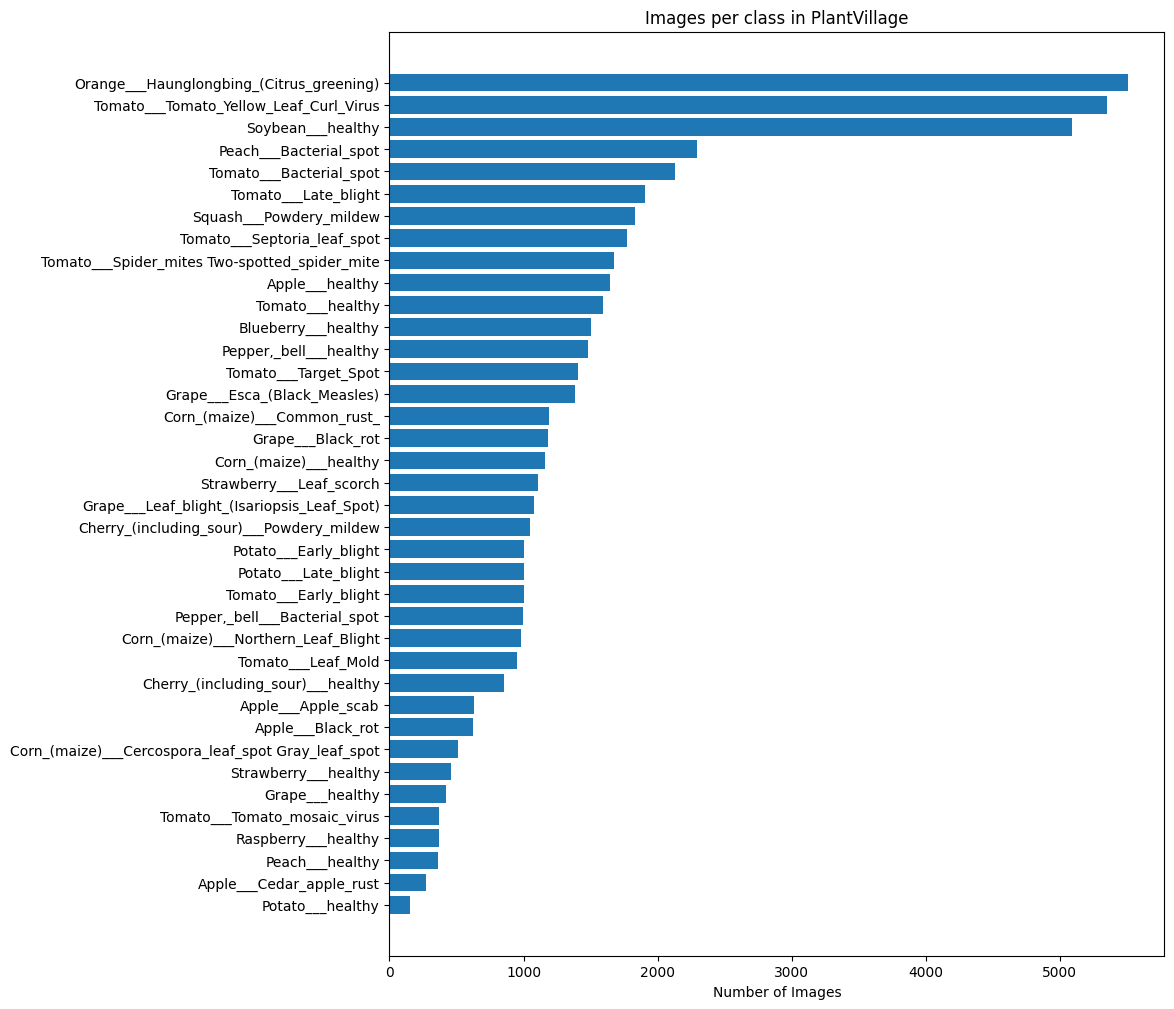

Total images: 54305


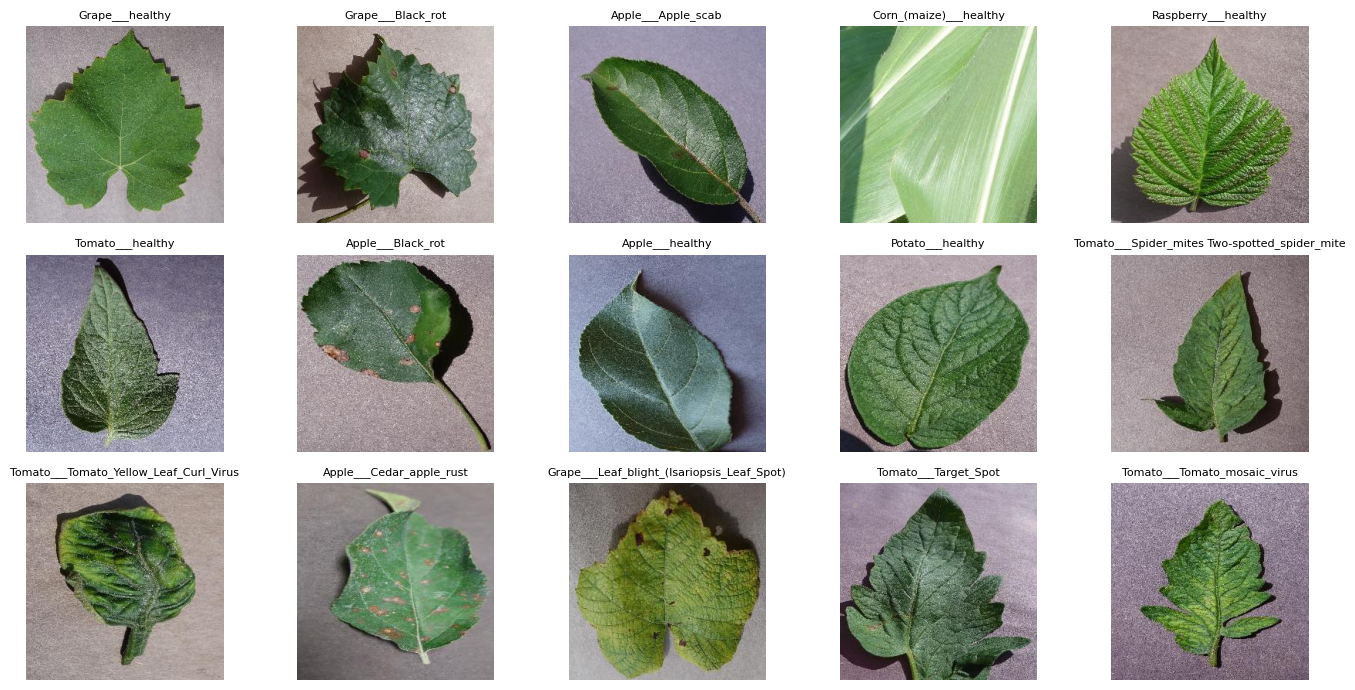

In [4]:
#checking path
# !ls -a
# !ls -a ./data/plantvillage\ dataset/color
#we will use color version


#exploring the dataset
import os
import matplotlib.pyplot as plt

DATA_DIR="data/plantvillage dataset/color"
class_folders=sorted(os.listdir(DATA_DIR))
print("number of classes:",len(class_folders))
#print(class_folders[:5])

#count the number of image files inside each class folder
import matplotlib.pyplot as plt

class_counts={}
for class_name in class_folders:
  class_path=os.path.join(DATA_DIR,class_name)
  #print("class path for", class_name ,class_path)
  if os.path.isdir(class_path):
    class_counts[class_name]=len(os.listdir(class_path))

#sorting classes
sorted_items=sorted(class_counts.items(),key=lambda x:x[1],reverse=True)
names=[item[0] for item in sorted_items]
counts=[item[1] for item in sorted_items]

plt.figure(figsize=(10,12))
plt.barh(names,counts)
plt.xlabel("Number of Images")
plt.title("Images per class in PlantVillage")
plt.gca().invert_yaxis()
plt.tight_layout
plt.show()

print("Total images:", sum(counts))


#observing samples
from PIL import Image
import random
sample_classes=random.sample(class_folders,15)

plt.figure(figsize=(14,7)) #fig dimension
for i,class_name in enumerate(sample_classes):
  class_path=os.path.join(DATA_DIR,class_name)
  image_name=os.listdir(class_path)[0]
  image_path=os.path.join(class_path, image_name)

  img=Image.open(image_path)
  plt.subplot(3,5,i+1)
  plt.imshow(img)
  plt.title(class_name, fontsize=8)
  plt.axis("off")

plt.tight_layout()
plt.show()



In [5]:
#train,val,test split
from torchvision import datasets, transforms
from torch.utils.data import random_split

basic_transform=transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
])

#image folder reads folder structure, each sub-folder becomes a class and to each class, an integer label is assigned.
full_dataset=datasets.ImageFolder(root=DATA_DIR, transform=basic_transform)
class_names=full_dataset.classes
num_classes=len(class_names)
print("number of classes:", num_classes)

total_size=len(full_dataset)
train_size=int(0.7*total_size)
val_size=int(0.15*total_size)
test_size=total_size-train_size-val_size

print("train,val,test:",train_size,val_size,test_size)

#fixing generator seed
generator=torch.Generator().manual_seed(42)
train_dataset,val_dataset,test_dataset=random_split(full_dataset,[train_size,val_size,test_size], generator=generator)


number of classes: 38
train,val,test: 38013 8145 8147


In [6]:
#transform and data augmentation

IMG_SIZE=128

train_transform=transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], #imagenet stats for mean for RGB channel
                         [0.229, 0.224, 0.225]) #imagenet stats for std for RGB channel
])

eval_transform=transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], #imagenet stats for mean for RGB channel
                         [0.229, 0.224, 0.225]) #imagenet stats for std for RGB channel
])


train_base=datasets.ImageFolder(root=DATA_DIR, transform=train_transform)
eval_base=datasets.ImageFolder(root=DATA_DIR, transform=eval_transform)

generator=torch.Generator().manual_seed(42)
train_split,_,_=random_split(train_base,[train_size,val_size,test_size], generator=generator)

generator=torch.Generator().manual_seed(42)
_,val_split,test_split=random_split(eval_base,[train_size,val_size,test_size], generator=generator)


In [7]:
#data loader
from torch.utils.data import DataLoader
BATCH_SIZE=32

train_loader=DataLoader(train_split, batch_size=BATCH_SIZE, shuffle=True)
val_loader=DataLoader(val_split, batch_size=BATCH_SIZE, shuffle=False)
test_loader=DataLoader(test_split, batch_size=BATCH_SIZE, shuffle=False)

# print(len(train_split))
# print(len(train_loader))

In [8]:
%pip install torchinfo

In [9]:
#cnn
import torch.nn as nn
import torch.nn.functional as F

from torchinfo import summary

class LeafDiseaseCNN(nn.Module):
  def __init__(self, num_classes):
    super().__init__()

    self.conv1=nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
    self.conv2=nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
    self.conv3=nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)

    self.pool=nn.MaxPool2d(kernel_size=2, stride=2)

    self.fc1=nn.Linear(128*IMG_SIZE//8*IMG_SIZE//8, 256)

    self.dropout=nn.Dropout(0.5)

    self.fc2=nn.Linear(256,num_classes)

  def forward(self,x):
    #convolution, relu, maxpool
    x=self.pool(F.relu(self.conv1(x)))
    x=self.pool(F.relu(self.conv2(x)))
    x=self.pool(F.relu(self.conv3(x)))

    #flatten
    x=x.view(x.size(0),-1)

    x=F.relu(self.fc1(x))
    x=self.dropout(x)

    x=self.fc2(x)

    return x

model=LeafDiseaseCNN(num_classes=num_classes).to(device)
print(model)

summary(model, input_size=(100,3,IMG_SIZE,IMG_SIZE)) #first parameter is number of images as a batch

LeafDiseaseCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=32768, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=38, bias=True)
)


Layer (type:depth-idx)                   Output Shape              Param #
LeafDiseaseCNN                           [100, 38]                 --
├─Conv2d: 1-1                            [100, 32, 128, 128]       896
├─MaxPool2d: 1-2                         [100, 32, 64, 64]         --
├─Conv2d: 1-3                            [100, 64, 64, 64]         18,496
├─MaxPool2d: 1-4                         [100, 64, 32, 32]         --
├─Conv2d: 1-5                            [100, 128, 32, 32]        73,856
├─MaxPool2d: 1-6                         [100, 128, 16, 16]        --
├─Linear: 1-7                            [100, 256]                8,388,864
├─Dropout: 1-8                           [100, 256]                --
├─Linear: 1-9                            [100, 38]                 9,766
Total params: 8,491,878
Trainable params: 8,491,878
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 17.45
Input size (MB): 19.66
Forward/backward pass size (MB): 734.24
Params size (MB): 33.97
Es

In [10]:
#loss
criterion=nn.CrossEntropyLoss()

#adam optimizer
optimizer=torch.optim.Adam(model.parameters(), lr=0.001)


In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):
  model.train()
  running_loss=0.0
  correct=0
  total=0

  for images,labels in loader:
    images=images.to(device)
    labels=labels.to(device)

    optimizer.zero_grad()

    outputs=model(images)

    loss=criterion(outputs, labels)

    loss.backward()

    optimizer.step()

    running_loss+=loss.item()*images.size(0)
    _,predicted=torch.max(outputs,1)
    correct+=(predicted==labels).sum().item()
    total+=labels.size(0)

  epoch_loss=running_loss/total
  epoch_acc=correct/total
  return epoch_loss, epoch_acc



def evaluate(model, loader, criterion, device):
  model.eval()
  running_loss=0.0
  correct=0
  total=0

  with torch.no_grad():
    for images,labels in loader:
      images=images.to(device)
      labels=labels.to(device)

      optimizer.zero_grad()

      outputs=model(images)

      loss=criterion(outputs, labels)

      running_loss+=loss.item()*images.size(0)
      _,predicted=torch.max(outputs,1)
      correct+=(predicted==labels).sum().item()
      total+=labels.size(0)

  epoch_loss=running_loss/total
  epoch_acc=correct/total
  return epoch_loss, epoch_acc


In [12]:
NUM_EPOCHS=10

history={"train_loss":[],"train_acc":[], "val_loss":[], "val_acc":[]}

for epoch in range(NUM_EPOCHS):
  train_loss,train_acc=train_one_epoch(model, train_loader, criterion, optimizer, device)
  val_loss, val_acc=evaluate(model,val_loader, criterion, device)

  history["train_acc"].append(train_acc)
  history["train_loss"].append(train_loss)
  history["val_acc"].append(val_acc)
  history["val_loss"].append(val_loss)

  print(f"epoch:{epoch+1}/{NUM_EPOCHS}")
  print(f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}")
  print(f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

print("complete")

epoch:1/10
train_loss=1.2527, train_acc=0.6384
val_loss=0.4698, val_acc=0.8545
epoch:2/10
train_loss=0.6207, train_acc=0.8090
val_loss=0.3040, val_acc=0.9118
epoch:3/10
train_loss=0.4659, train_acc=0.8541
val_loss=0.2682, val_acc=0.9182
epoch:4/10
train_loss=0.3762, train_acc=0.8816
val_loss=0.2964, val_acc=0.9058
epoch:5/10
train_loss=0.3201, train_acc=0.9006
val_loss=0.1792, val_acc=0.9459
epoch:6/10
train_loss=0.2815, train_acc=0.9109
val_loss=0.1694, val_acc=0.9487
epoch:7/10
train_loss=0.2606, train_acc=0.9168
val_loss=0.1624, val_acc=0.9542
epoch:8/10
train_loss=0.2244, train_acc=0.9289
val_loss=0.1631, val_acc=0.9562
epoch:9/10
train_loss=0.2213, train_acc=0.9300
val_loss=0.1547, val_acc=0.9560
epoch:10/10
train_loss=0.2058, train_acc=0.9357
val_loss=0.1369, val_acc=0.9634
complete


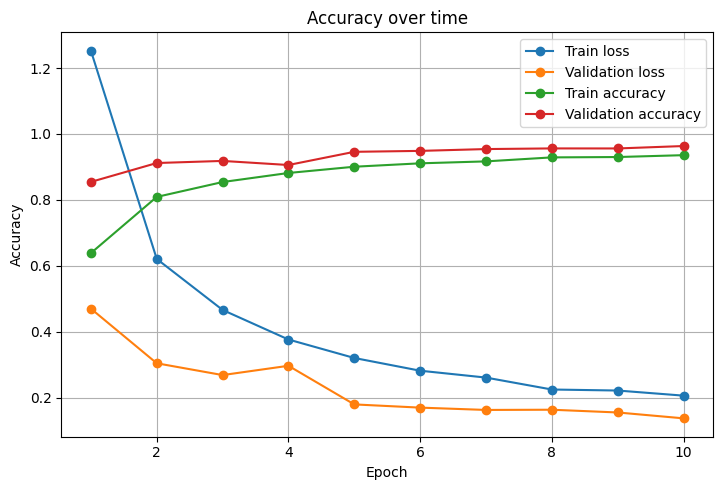

In [13]:
#plotting curves
epochs_range=range(1,NUM_EPOCHS+1)
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, history["train_loss"],marker="o",label="Train loss")
plt.plot(epochs_range,history["val_loss"],marker="o",label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over time")
plt.legend()
plt.grid(True)


plt.subplot(1,2,1)
plt.plot(epochs_range, history["train_acc"],marker="o",label="Train accuracy")
plt.plot(epochs_range,history["val_acc"],marker="o",label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy over time")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [14]:
#evaluate on testset

test_loss,test_acc=evaluate(model,test_loader,criterion, device)
print("test_loss:",test_loss)
print("test_acc:",test_acc)


test_loss: 0.17813677551039409
test_acc: 0.9576531238492697


                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.79      0.89      0.84        91
                                 Apple___Black_rot       0.95      0.97      0.96        87
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        37
                                   Apple___healthy       0.96      0.93      0.94       270
                               Blueberry___healthy       0.95      0.96      0.96       198
          Cherry_(including_sour)___Powdery_mildew       0.98      0.97      0.97       176
                 Cherry_(including_sour)___healthy       0.90      0.98      0.94       125
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.83      0.83      0.83        71
                       Corn_(maize)___Common_rust_       0.99      0.99      0.99       168
               Corn_(maize)___Northern_Leaf_Blight       0.92      0.92      0.

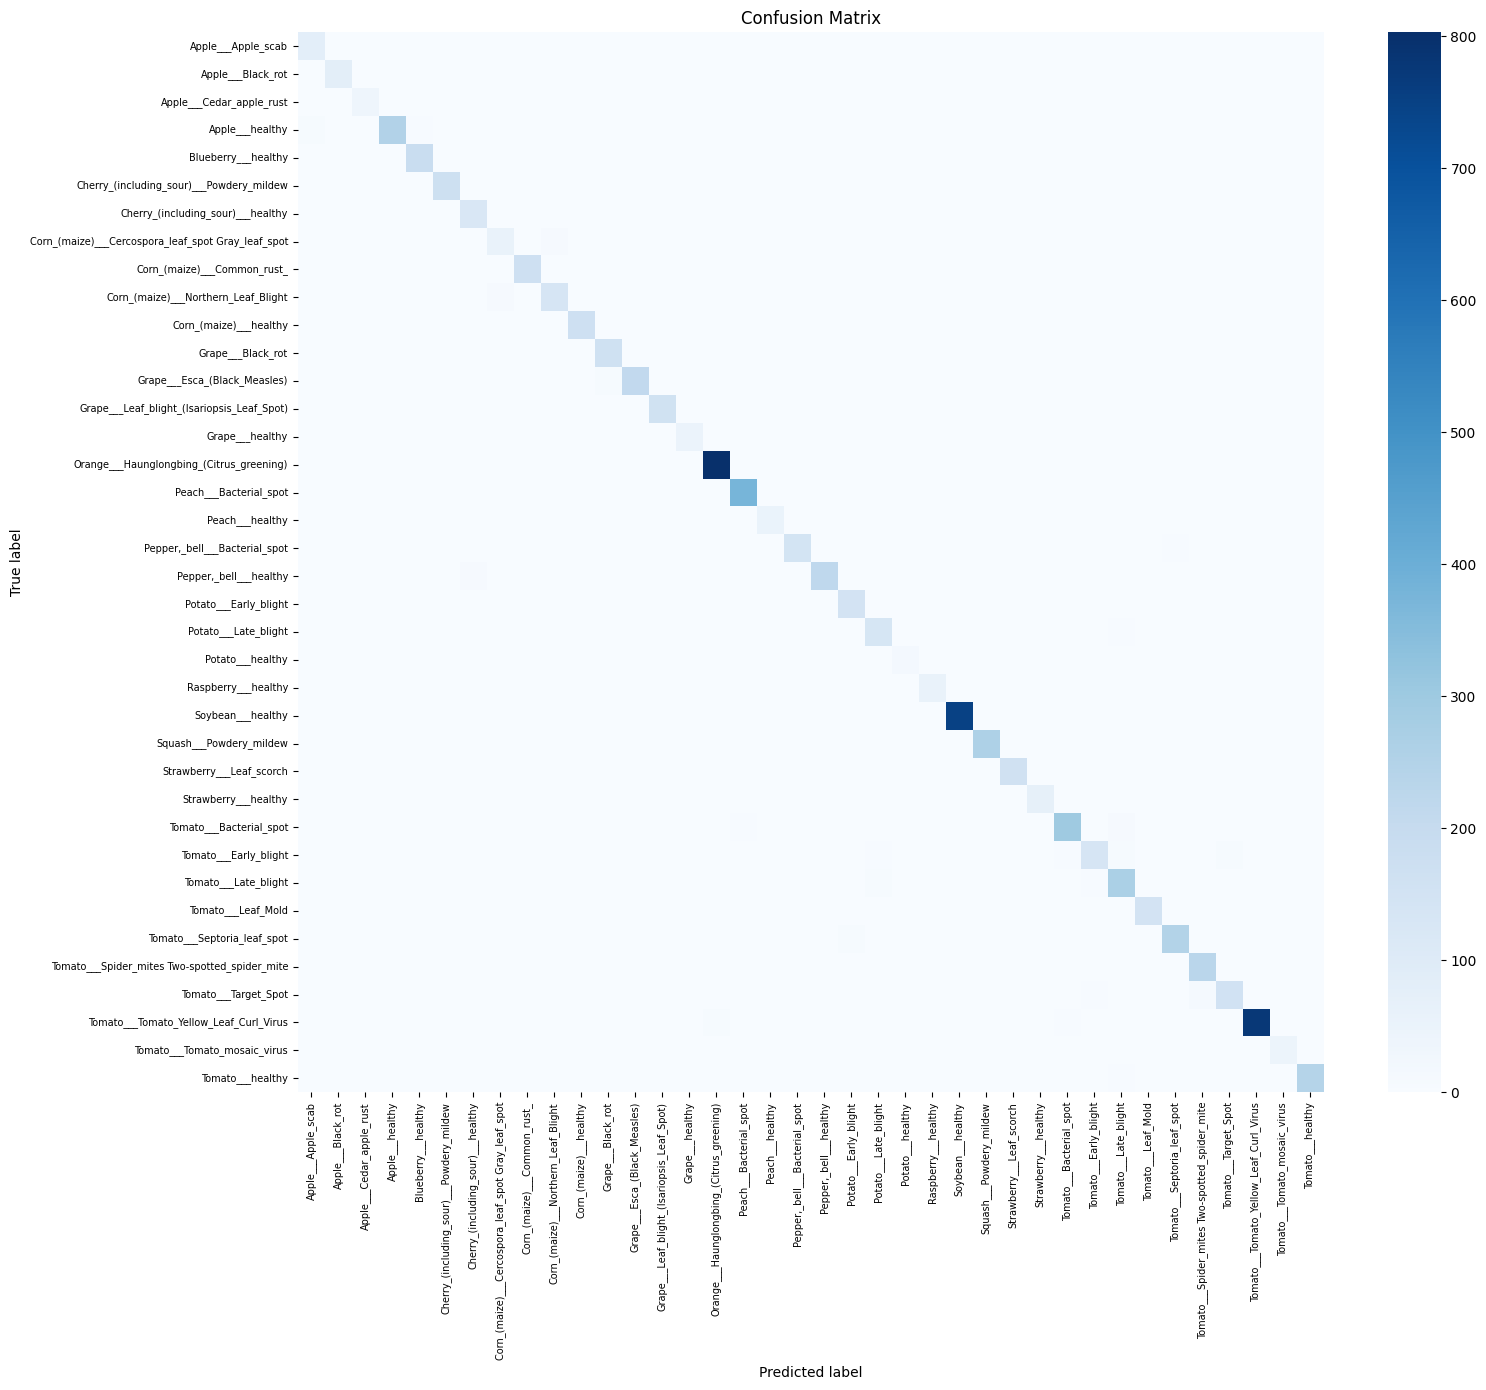

In [17]:
#confusion matrix and classification report
all_predictions=[]
all_true_labels=[]

model.eval()
with torch.no_grad():
  for images,labels in test_loader:
    images=images.to(device)
    outputs=model(images)
    _,predicted=torch.max(outputs,1)

    all_predictions.extend(predicted.cpu().numpy())
    all_true_labels.extend(labels.numpy())

  from sklearn.metrics import classification_report
  report=classification_report(all_true_labels,all_predictions, target_names=class_names)
  print(report)


  from sklearn.metrics import confusion_matrix
  import seaborn as sns



cm=confusion_matrix(all_true_labels, all_predictions)
plt.figure(figsize=(16,14))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()


In [27]:
REAL_LEAVES_DIR="real_leaves"
os.makedirs(REAL_LEAVES_DIR, exist_ok=True)


from google.colab import files
uploaded=files.upload()

import shutil
for filename in uploaded.keys():
  shutil.move(filename,os.path.join(REAL_LEAVES_DIR, filename))

print(os.listdir(REAL_LEAVES_DIR))

#testing on real leaves data
model.eval()
real_images=os.listdir(REAL_LEAVES_DIR)

plt.figure(figsize=(15, 16))

for i, filename in enumerate(real_images):
  image_path=os.path.join(REAL_LEAVES_DIR,filename)

  original_image=Image.open(image_path).convert("RGB")
  input_tensor=eval_transform(original_image).unsqueeze(0).to(device)

  with torch.no_grad():
    output=model(input_tensor)
    probabilities=F.softmax(output,dim=1)
    confidence,predicted_index=torch.max(probabilities,1)

  predicted_class=class_names[predicted_index.item()]
  confidence_percent=confidence.item()*100

  plt.subplot(4,3,i+1)
  plt.imshow(original_image)
  plt.title(f"{predicted_class}\nConfidence: {confidence_percent:.1f}", fontsize=9)
  plt.axis("off")

plt.tight_layout()
plt.show()


Output hidden; open in https://colab.research.google.com to view.